# Notebook 07: Training Loop

## Overview

- **Duration**: ~3 hours (including training time)
- **Prerequisites**: Notebooks 01-06
- **Learning Objectives**:
  1. Configure AdamW optimizer correctly
  2. Implement learning rate scheduling with warmup
  3. Implement a complete training loop
  4. Track metrics and save checkpoints
  5. Train a small GPT model!

In [3]:
import sys
sys.path.insert(0, '../..')

import math
import time
from pathlib import Path
from dataclasses import dataclass

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cpu


## Load Model and Data

In [4]:
#define GPT
import torch
import torch.nn as nn
import torch.nn.functional as F
import math


class GPTConfig:
    def __init__(self, vocab_size, block_size, n_layer=4, n_head=4, n_embd=128, dropout=0.0, bias=False):
        self.vocab_size = vocab_size
        self.block_size = block_size
        self.n_layer = n_layer
        self.n_head = n_head
        self.n_embd = n_embd
        self.dropout = dropout
        self.bias = bias


class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=config.n_embd,
            num_heads=config.n_head,
            batch_first=True
        )
        self.register_buffer(
            "mask",
            torch.tril(torch.ones(config.block_size, config.block_size))
        )

    def forward(self, x):
        B, T, C = x.size()
        mask = self.mask[:T, :T]
        x, _ = self.attn(x, x, x, attn_mask=(mask == 0))
        return x


class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.mlp = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.GELU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.token_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)

        self.blocks = nn.Sequential(
            *[Block(config) for _ in range(config.n_layer)]
        )

        self.ln_f = nn.LayerNorm(config.n_embd)
        self.head = nn.Linear(config.n_embd, config.vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        device = idx.device

        pos = torch.arange(0, T, device=device)
    
        tok = self.token_emb(idx)
        pos = self.pos_emb(pos)

        x = tok + pos
        x = self.blocks(x)
        x = self.ln_f(x)

        logits = self.head(x)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

In [5]:
# Import model
# Configuration for a small model (good for experimentation)
config = GPTConfig(
    vocab_size=10000,
    block_size=256,
    n_layer=6,
    n_head=6,
    n_embd=384,
    dropout=0.1,
    bias=False,
)

model = GPT(config).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 18,435,856


In [6]:
# Load preprocessed data from Notebook 06
from torch.utils.data import Dataset

class TextDataset(Dataset):
    def __init__(self, tokens, block_size):
        self.tokens = tokens
        self.block_size = block_size
    def __len__(self):
        return len(self.tokens) - self.block_size
    def __getitem__(self, idx):
        chunk = self.tokens[idx:idx + self.block_size + 1]
        return torch.tensor(chunk[:-1], dtype=torch.long), torch.tensor(chunk[1:], dtype=torch.long)

data_path = Path("data")
if data_path.exists():
    train_tokens = np.load(data_path / "train_tokens.npy")
    val_tokens = np.load(data_path / "val_tokens.npy")
else:
    # Generate some dummy data if not available
    print("Data not found, using random tokens for demo...")
    train_tokens = np.random.randint(0, config.vocab_size, 100000)
    val_tokens = np.random.randint(0, config.vocab_size, 10000)

train_dataset = TextDataset(train_tokens, config.block_size)
val_dataset = TextDataset(val_tokens, config.block_size)

print(f"Train samples: {len(train_dataset):,}")
print(f"Val samples: {len(val_dataset):,}")

Train samples: 9,440,713
Val samples: 1,048,741


## Exercise 7.1: Learning Rate Schedule (30 min)

Implement a learning rate schedule with:
1. **Linear warmup**: Gradually increase LR from 0 to max_lr
2. **Cosine decay**: Smoothly decrease LR to min_lr

In [7]:
####solution 7.1
def get_lr(step: int, warmup_steps: int, max_steps: int, max_lr: float, min_lr: float) -> float:
    """
    Compute learning rate with linear warmup and cosine decay.
    
    Args:
        step: Current training step
        warmup_steps: Number of warmup steps
        max_steps: Total training steps
        max_lr: Peak learning rate
        min_lr: Minimum learning rate
        
    Returns:
        Learning rate for current step
    """
    # TODO: Implement the learning rate schedule
    # 1. If step < warmup_steps: linear warmup from 0 to max_lr
    if step < warmup_steps:
        return max_lr * (step / warmup_steps)
    # 2. If step > max_steps: return min_lr
    if step > max_steps:
        return min_lr
    # 3. Otherwise: cosine decay from max_lr to min_lr
    #    decay_ratio = (step - warmup_steps) / (max_steps - warmup_steps)
    decay_ratio = (step - warmup_steps) / (max_steps - warmup_steps)
    #    coeff = 0.5 * (1 + cos(pi * decay_ratio))
    coeff = 0.5 * (1 + math.cos(math.pi * decay_ratio))
    #    return min_lr + coeff * (max_lr - min_lr)
    return min_lr + coeff * (max_lr - min_lr)

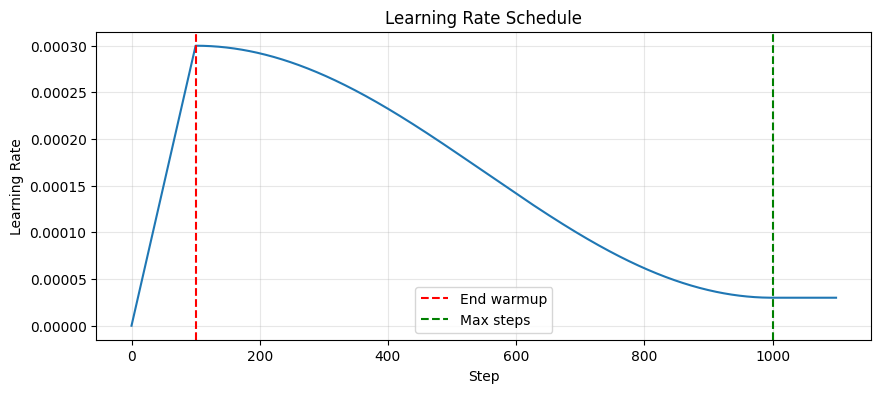

LR at step 0: 0.00e+00
LR at step 100: 3.00e-04
LR at step 1000: 3.00e-05


In [8]:
####test cell
# Test and visualize the schedule
warmup_steps = 100
max_steps = 1000
max_lr = 3e-4
min_lr = 3e-5

lrs = [get_lr(i, warmup_steps, max_steps, max_lr, min_lr) for i in range(max_steps + 100)]

plt.figure(figsize=(10, 4))
plt.plot(lrs)
plt.axvline(warmup_steps, color='r', linestyle='--', label='End warmup')
plt.axvline(max_steps, color='g', linestyle='--', label='Max steps')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"LR at step 0: {lrs[0]:.2e}")
print(f"LR at step {warmup_steps}: {lrs[warmup_steps]:.2e}")
print(f"LR at step {max_steps}: {lrs[max_steps]:.2e}")

## Exercise 7.2: Configure Optimizer (20 min)

Configure AdamW with proper weight decay groups.

In [9]:
####solutio 7.2
def configure_optimizer(model: nn.Module, weight_decay: float, learning_rate: float, betas: tuple):
    """
    Configure AdamW optimizer with weight decay only on appropriate parameters.
    
    Weight decay should NOT be applied to:
    - Biases
    - LayerNorm parameters
    - Embedding parameters (debatable, but common practice)
    """
    # TODO: Separate parameters into decay and no-decay groups
    # Hint: Check param.ndim (1D params are usually biases/norms)
    # or check the parameter name for 'bias', 'ln', 'norm'

    decay_params = []
    no_decay_params = []
    for name, param in model.named_parameters():
        if param.ndim == 1 or 'bias' in name.lower() or 'ln' in name.lower() or 'norm' in name.lower() or 'embedding' in name.lower():
            no_decay_params.append(param)
        else:
            decay_params.append(param)
    # Create optimizer with two parameter groups
    optimizer = torch.optim.AdamW([
        {'params': decay_params, 'weight_decay': weight_decay},
        {'params': no_decay_params, 'weight_decay': 0.0}
    ], lr=learning_rate, betas=betas)
    return optimizer 

In [10]:
# Create optimizer
optimizer = configure_optimizer(
    model,
    weight_decay=0.1,
    learning_rate=max_lr,
    betas=(0.9, 0.95),
)
print(f"Optimizer created with {len(optimizer.param_groups)} parameter groups")

Optimizer created with 2 parameter groups


## Exercise 7.3: Training Loop (45 min)

In [11]:
@dataclass
class TrainingConfig:
    # Optimization
    max_steps: int = 1000
    warmup_steps: int = 100
    max_lr: float = 3e-4
    min_lr: float = 3e-5
    weight_decay: float = 0.1
    grad_clip: float = 1.0
    
    # Batch
    batch_size: int = 32
    
    # Logging
    log_interval: int = 10
    eval_interval: int = 100
    save_interval: int = 500

In [12]:
@torch.no_grad()
def evaluate(model, dataloader, max_batches=50):
    """Evaluate model on a dataset."""
    model.eval()
    losses = []
    
    for i, (x, y) in enumerate(dataloader):
        if i >= max_batches:
            break
        x, y = x.to(device), y.to(device)
        _, loss = model(x, y)
        losses.append(loss.item())
    
    model.train()
    return np.mean(losses)

In [14]:
####solution 7.3
def train(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    config: TrainingConfig,
):
    """
    Train the model.
    
    Returns:
        Dictionary with training history
    """
    history = {"train_loss": [], "val_loss": [], "lr": []}
    
    model.train()
    train_iter = iter(train_loader)
    
    pbar = tqdm(range(config.max_steps), desc="Training")
    
    for step in pbar:        
        # TODO: Implement the training loop
        # 1. Update learning rate
        #    lr = get_lr(step, config.warmup_steps, config.max_steps, config.max_lr, config.min_lr)
        #    for param_group in optimizer.param_groups:
        #        param_group['lr'] = lr
        lr = get_lr(step, config.warmup_steps, config.max_steps, config.max_lr, config.min_lr)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr
        
        # 2. Get batch (cycle through dataloader)
        #    try: x, y = next(train_iter)
        #    except StopIteration: train_iter = iter(train_loader); x, y = next(train_iter)
        try:
            x, y = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            x, y = next(train_iter)
        
        # 3. Forward pass
        #    x, y = x.to(device), y.to(device)
        #    logits, loss = model(x, y)
        x, y = x.to(device), y.to(device)
        logits, loss = model(x, y)
        
        # 4. Backward pass
        #    optimizer.zero_grad(set_to_none=True)
        #    loss.backward()
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        
        # 5. Gradient clipping
        #    torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)
        
        # 6. Optimizer step
        #    optimizer.step()
        optimizer.step()
        
        # 7. Logging
        #    if step % config.log_interval == 0:
        #        history["train_loss"].append(loss.item())
        #        history["lr"].append(lr)
        #        pbar.set_postfix({"loss": f"{loss.item():.4f}", "lr": f"{lr:.2e}"})
        if step % config.log_interval == 0:
            history["train_loss"].append(loss.item())
            history["lr"].append(lr)
            pbar.set_postfix({"loss": f"{loss.item():.4f}", "lr": f"{lr:.2e}"})
        
        # 8. Evaluation
        #    if step % config.eval_interval == 0:
        #        val_loss = evaluate(model, val_loader)
        #        history["val_loss"].append(val_loss)
        #        tqdm.write(f"Step {step}: val_loss = {val_loss:.4f}")
        if step % config.eval_interval == 0:
            val_loss = evaluate(model, val_loader)
            history["val_loss"].append(val_loss)
            tqdm.write(f"Step {step}: val_loss = {val_loss:.4f}")
    
    return history

In [15]:
# Create dataloaders
train_config = TrainingConfig(max_steps=500, batch_size=32)

train_loader = DataLoader(train_dataset, batch_size=train_config.batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=train_config.batch_size, shuffle=False, drop_last=True)

# Reset model and optimizer
model = GPT(config).to(device)
optimizer = configure_optimizer(model, train_config.weight_decay, train_config.max_lr, (0.9, 0.95))

In [16]:
# Train!
print("Starting training...")
start_time = time.time()

history = train(model, train_loader, val_loader, optimizer, train_config)

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed/60:.1f} minutes")

Starting training...


Training:   0%|          | 0/500 [00:00<?, ?it/s]

Step 0: val_loss = 9.4333
Step 100: val_loss = 4.6139
Step 200: val_loss = 3.8378
Step 300: val_loss = 3.6181
Step 400: val_loss = 3.4901

Training completed in 125.4 minutes


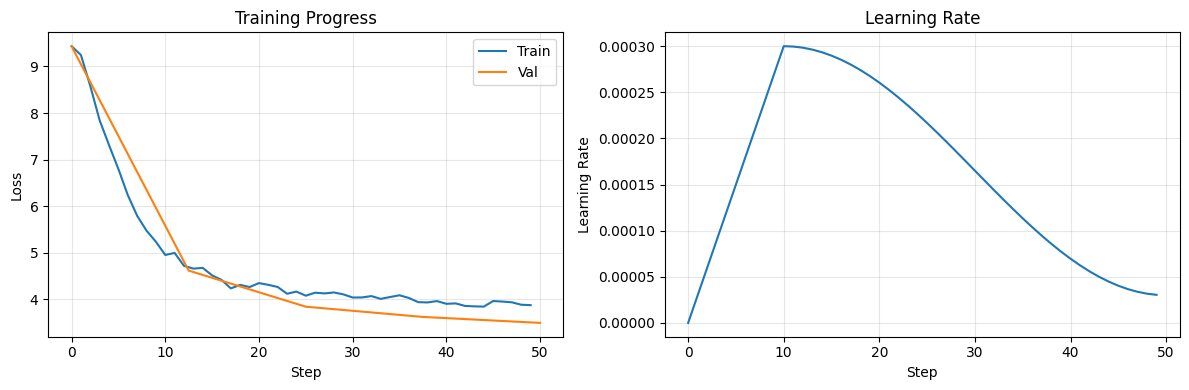

In [17]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(history["train_loss"], label="Train")
if history["val_loss"]:
    val_steps = np.linspace(0, len(history["train_loss"]), len(history["val_loss"]))
    ax.plot(val_steps, history["val_loss"], label="Val")
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training Progress")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(history["lr"])
ax.set_xlabel("Step")
ax.set_ylabel("Learning Rate")
ax.set_title("Learning Rate")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Save Checkpoint

In [18]:
# Save the trained model
checkpoint_path = Path("checkpoints")
checkpoint_path.mkdir(exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "config": config,
    "history": history,
}, checkpoint_path / "gpt_checkpoint.pt")

print(f"Saved checkpoint to {checkpoint_path}/gpt_checkpoint.pt")

Saved checkpoint to checkpoints/gpt_checkpoint.pt


## Summary

### What You Learned

1. **LR Schedule**: Warmup + cosine decay
2. **AdamW**: Weight decay on appropriate parameters only
3. **Gradient Clipping**: Prevent exploding gradients
4. **Training Loop**: Forward, backward, clip, step

### Next: Advanced Training

In Notebook 08, we'll add mixed precision and gradient accumulation for faster training!